<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:
## Write your code here

# -------------------------------
# Task 1: Display Basic Information
# -------------------------------

# Display dataset shape
print("Dataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display summary statistics for numerical columns
print("\nSummary Statistics (Numerical Columns):")
print(df.describe())

# Display summary statistics for all columns
print("\nSummary Statistics (All Columns):")
print(df.describe(include='all'))

# Display first 5 rows
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(65447, 114)

Column Names:
Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB

Summary Statistics (Numerical Columns):
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65447.000000   3.374000e+04  29659.000000    29325.000000   
mean   32714.001528  2.963841e+145     11.467143       18.580460   
std    18893.063225  5.444117e+147      9.168610       25.966005   
min        1.000000   0.000000e+00      0.000000        0.000000  

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:
## Write your code here

# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

# Display only the columns with missing values
print("\nColumns with Missing Values:")
print(missing_values[missing_values > 0])

# Total missing values in the dataset
print("\nTotal Missing Values in Dataset:")
print(df.isnull().sum().sum())

Missing Values in Each Column:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64

Columns with Missing Values:
RemoteWork             10635
CodingActivities       10975
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16202
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 109, dtype: int64

Total Missing Values in Dataset:
2891627


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



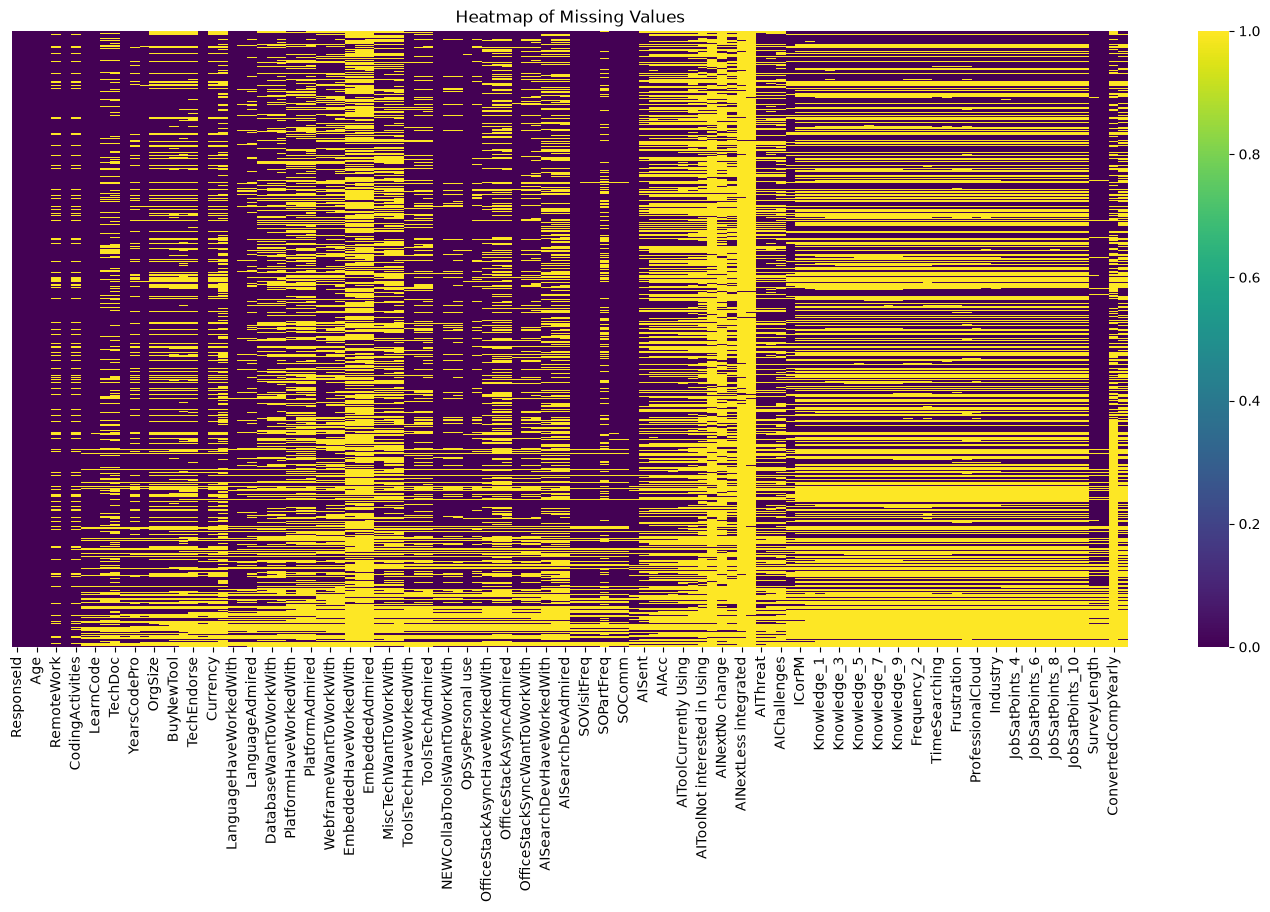

In [7]:
## Write your code here

# Set figure size
plt.figure(figsize=(18, 8))

# Create heatmap of missing values
sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='viridis',
    yticklabels=False
)

# Add title
plt.title("Heatmap of Missing Values")

# Display the plot
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [8]:
## Write your code here

# Count missing values in the Employment column
missing_employment = df['Employment'].isnull().sum()

print("Number of missing rows in Employment column:", missing_employment)

# Display rows where Employment is missing
df[df['Employment'].isnull()].head()

Number of missing rows in Employment column: 0


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [10]:
## Write your code here

majority_value = df['Employment'].mode()[0]

print("Most Frequent (Majority) Value in Employment:")
print(majority_value)

# Count of the most frequent value
print(df['Employment'].value_counts().head())

Most Frequent (Majority) Value in Employment:
Employed, full-time
Employment
Employed, full-time                                                         39046
Independent contractor, freelancer, or self-employed                         4847
Student, full-time                                                           4712
Employed, full-time;Independent contractor, freelancer, or self-employed     3557
Not employed, but looking for work                                           2341
Name: count, dtype: int64


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [ ]:
## Write your code here

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


In [ ]:
## Write your code here

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
